In [ ]:
## importing libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns




In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [4]:
import os
print(os.getcwd())


C:\Users\navin\Downloads\copyy


In [5]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [6]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[198.   211.   191.  ]
   [203.5  216.5  196.5 ]
   [187.75 200.75 180.75]
   ...
   [240.5  252.25 225.  ]
   [232.25 246.25 211.25]
   [220.75 237.5  196.25]]

  [[197.5  210.5  190.5 ]
   [189.25 202.25 182.25]
   [201.5  214.5  194.5 ]
   ...
   [231.25 245.25 213.5 ]
   [220.   236.25 197.  ]
   [184.25 201.25 157.5 ]]

  [[196.25 209.25 189.25]
   [210.   223.   203.  ]
   [205.5  218.5  198.5 ]
   ...
   [214.75 230.75 194.  ]
   [182.5  201.   156.5 ]
   [154.5  175.25 125.  ]]

  ...

  [[217.   221.   195.5 ]
   [206.5  213.25 182.5 ]
   [201.   211.5  176.  ]
   ...
   [ 73.25  88.    58.75]
   [ 61.5   75.5   46.5 ]
   [ 60.75  73.25  44.75]]

  [[190.   195.5  162.  ]
   [197.75 205.5  168.75]
   [186.25 198.25 156.  ]
   ...
   [ 82.75  89.    65.5 ]
   [ 97.    99.5   77.25]
   [ 85.25  86.75  64.75]]

  [[200.25 206.25 168.75]
   [189.75 198.   157.  ]
   [176.   188.   143.5 ]
   ...
   [ 63.25  63.75  43.25]
   [ 80.    76.    57.  ]
   [ 87.75  81.75  6

In [7]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [8]:
model = Sequential()

In [9]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))



In [10]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3])) 
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))



In [11]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3])) 
model.add(Conv2D(filters=128,kernel_size=3,activation='relu')) 
model.add(MaxPool2D(pool_size=2,strides=2))



In [12]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
 


In [14]:
model.add(Dropout(0.25))

In [15]:
model.add(Flatten())

In [16]:
model.add(Dense(units=1500,activation='relu'))

In [17]:
model.add(Dropout(0.4))   

In [18]:
model.add(Dense(units=38,activation='softmax'))

In [19]:
model.compile(optimizer=tf.optimizers.Adam(
      learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [21]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=5)

Epoch 1/5
2197/2197 [==============================] - 4152s 2s/step - loss: 1.3476 - accuracy: 0.6052 - val_loss: 0.4880 - val_accuracy: 0.8454
Epoch 2/5
2197/2197 [==============================] - 3930s 2s/step - loss: 0.4336 - accuracy: 0.8621 - val_loss: 0.3182 - val_accuracy: 0.8998
Epoch 3/5
2197/2197 [==============================] - 3960s 2s/step - loss: 0.2657 - accuracy: 0.9151 - val_loss: 0.2228 - val_accuracy: 0.9290
Epoch 4/5
2197/2197 [==============================] - 3939s 2s/step - loss: 0.1851 - accuracy: 0.9406 - val_loss: 0.1598 - val_accuracy: 0.9505
Epoch 5/5
2197/2197 [==============================] - 3948s 2s/step - loss: 0.1385 - accuracy: 0.9546 - val_loss: 0.2268 - val_accuracy: 0.9285


In [22]:
train_loss,train_acc = model.evaluate(training_set)

2197/2197 [==============================] - 980s 446ms/step - loss: 0.1242 - accuracy: 0.9569


In [23]:
print(train_loss,train_acc)

0.12422327697277069 0.9569101929664612


In [24]:
val_loss,val_acc = model.evaluate(validation_set)

550/550 [==============================] - 246s 447ms/step - loss: 0.2268 - accuracy: 0.9285


In [25]:
print(val_loss,val_acc)

0.22682519257068634 0.9285226464271545


In [26]:
model.save("trained_set.h5")

In [27]:
model.save("trained_set.keras")

In [28]:
training_history.history

{'loss': [1.3476217985153198,
  0.4335509240627289,
  0.26571908593177795,
  0.18509486317634583,
  0.1384979635477066],
 'accuracy': [0.60517817735672,
  0.8621239066123962,
  0.9150579571723938,
  0.9406074285507202,
  0.9546340703964233],
 'val_loss': [0.48798176646232605,
  0.31824108958244324,
  0.22283774614334106,
  0.15981988608837128,
  0.22682514786720276],
 'val_accuracy': [0.8454359173774719,
  0.899783730506897,
  0.9290348291397095,
  0.9504894018173218,
  0.9285226464271545]}

In [29]:
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

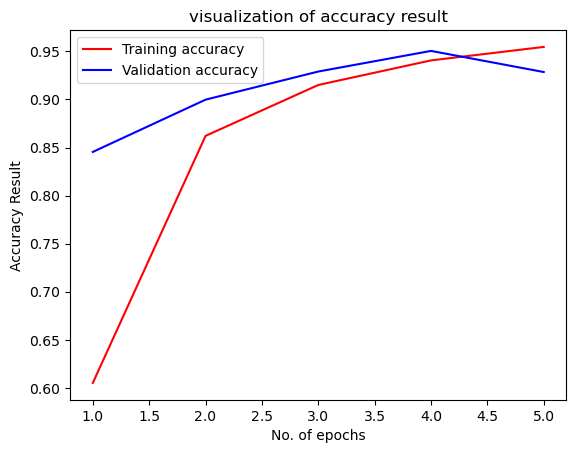

In [32]:
epochs=[i for i in range(1,6)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation accuracy')
plt.xlabel("No. of epochs")
plt.ylabel("Accuracy Result")
plt.title("visualization of accuracy result")
plt.legend()
plt.show()

In [52]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [51]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [35]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

17572/17572 [==============================] - 392s 22ms/step


(array([[9.9755532e-01, 2.6701232e-06, 6.7127587e-08, ..., 1.9802089e-11,
         3.7146999e-10, 5.1040167e-10],
        [9.9909770e-01, 4.4905124e-04, 6.5165127e-06, ..., 5.6717901e-09,
         8.3210496e-09, 8.7157169e-08],
        [9.9704021e-01, 5.9197185e-09, 3.6013415e-07, ..., 2.9041552e-12,
         1.1595851e-10, 2.3263329e-08],
        ...,
        [2.6077371e-09, 6.6751243e-13, 1.8103425e-08, ..., 5.2178665e-12,
         6.5526148e-12, 9.9999893e-01],
        [4.1318575e-08, 3.0248703e-11, 3.7910127e-08, ..., 4.7661497e-10,
         7.9175645e-11, 9.9999750e-01],
        [1.5947422e-12, 2.7496818e-12, 1.7913385e-12, ..., 5.3767066e-13,
         2.4902134e-11, 9.9998426e-01]], dtype=float32),
 (17572, 38))

In [36]:
predicted_categories=tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [37]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [38]:
y_true=tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [43]:
from sklearn.metrics import classification_report,confusion_matrix

In [44]:
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.88      0.92       504
                                 Apple___Black_rot       0.99      0.97      0.98       497
                          Apple___Cedar_apple_rust       0.96      0.94      0.95       440
                                   Apple___healthy       0.97      0.85      0.91       502
                               Blueberry___healthy       0.88      0.98      0.93       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       421
                 Cherry_(including_sour)___healthy       0.96      0.98      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.90      0.87       410
                       Corn_(maize)___Common_rust_       0.95      0.99      0.97       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.83      0.

In [46]:
cm =confusion_matrix(y_true,predicted_categories)
cm.shape

(38, 38)

In [47]:
cm =confusion_matrix(y_true,predicted_categories)
cm

array([[441,   3,   2, ...,   0,   0,   0],
       [  1, 482,   1, ...,   0,   0,   0],
       [  0,   0, 413, ...,   4,   0,   0],
       ...,
       [  0,   0,   0, ..., 487,   0,   0],
       [  0,   0,   0, ...,   0, 433,   0],
       [  0,   0,   0, ...,   0,   0, 475]], dtype=int64)

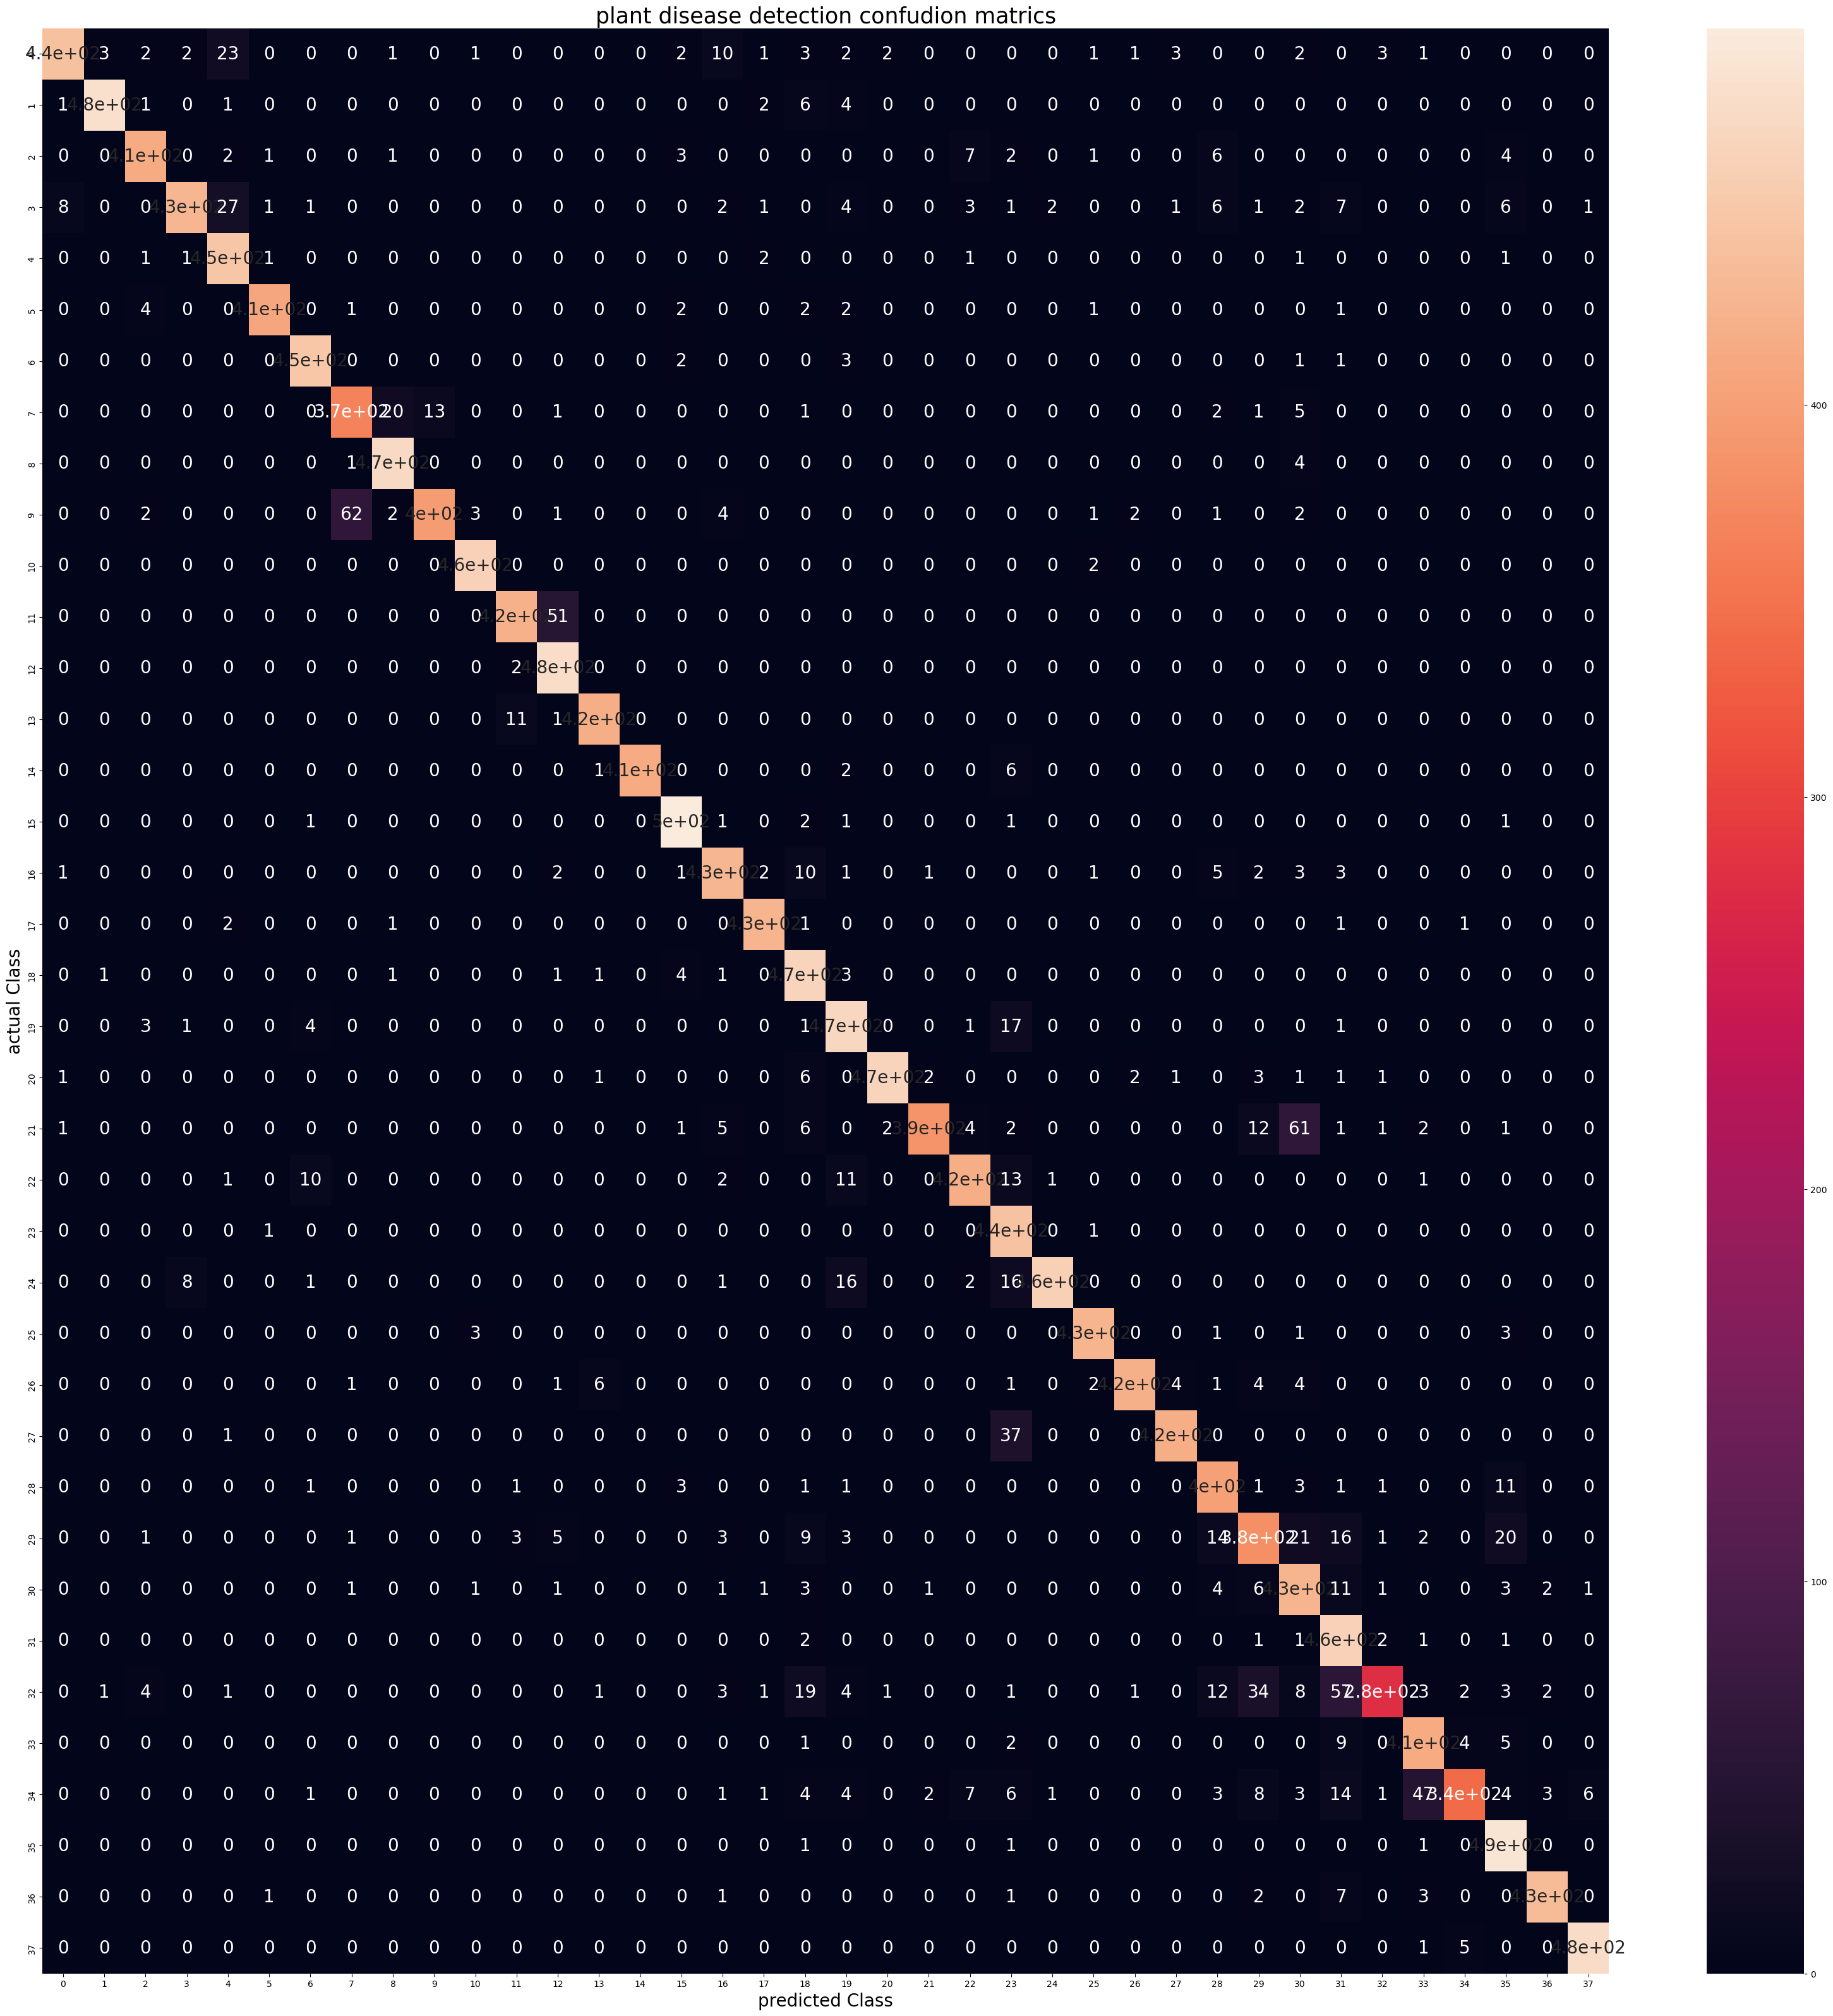

In [49]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':20})
plt.xlabel("predicted Class",fontsize=20)
plt.ylabel("actual Class",fontsize=20)
plt.title("plant disease detection confudion matrics",fontsize=25)
plt.show()